Clark UC Model for Real GDP Decomposition - Uzbekistan

Using statsmodels UnobservedComponents class

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [4]:
# ============================================================================
# 1. IMPORT DATA
# ============================================================================

# Read Excel file
file_path   = 'input\\data.xlsx'                            # Change to your file name
data        = pd.read_excel(file_path, sheet_name=0)        # First sheet

print("Column names in file:", data.columns.tolist())

# Take natural log of GDP (standard for Clark UC model)
data['log_rgdp'] = np.log(data.rgdp)

# Create quarterly frequency index
quarter_index = pd.date_range(start='2016-01-01', 
                              periods=len(data.log_rgdp), 
                              freq='QE')

print(f"\nData shape: {len(data.log_rgdp)} observations")
print(f"Period: {quarter_index[0]} to {quarter_index[-1]}")

Column names in file: ['date', 'rgdp']

Data shape: 40 observations
Period: 2016-03-31 00:00:00 to 2025-12-31 00:00:00


Clark UC Model Specification:

y_t = tau_t + c_t + e_t    (observed = trend + cycle + irregular)

Trend (tau_t): Random walk with drift

tau_t = tau_{t-1} + mu_{t-1} + eta_t
mu_t = mu_{t-1} + zeta_t    (drift follows random walk)

Cycle (c_t): AR(2) process

c_t = phi1 * c_{t-1} + phi2 * c_{t-2} + epsilon_t
Irregular: e_t ~ N(0, sigma_e^2)

In [5]:
# Model specifications

# Model, using string specification
model_spec = {
    'level': 'local linear trend', 'irregular': True, 'autoregressive': 2
}

In [6]:
# Output
output_mod = sm.tsa.UnobservedComponents(data.log_rgdp, **model_spec)
output_res = output_mod.fit(method='lbfgs', maxiter=1000, disp=True)
print("\nModel estimation successful!\n")
print(output_res.summary())

c:\Users\u.nurmatov\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\structural.py:426: SpecificationWarning: Value of `irregular` may be overridden when the trend component is specified using a model string.
  warn("Value of `%s` may be overridden when the trend"
c:\Users\u.nurmatov\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\filters\hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)



Model estimation successful!

                        Unobserved Components Results                         
Dep. Variable:               log_rgdp   No. Observations:                   40
Model:             local linear trend   Log Likelihood                 136.469
                              + AR(2)   AIC                           -260.938
Date:                Wed, 22 Apr 2026   BIC                           -251.112
Time:                        12:05:38   HQIC                          -257.442
Sample:                             0                                         
                                 - 40                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.577e-06   1.81e-05      0.087      0.931    -3.4e-05    3.71e-05
sig

c:\Users\u.nurmatov\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\structural.py:1738: RuntimeWarning: invalid value encountered in sqrt
  std_errors = np.sqrt(component_bunch['%s_cov' % which])


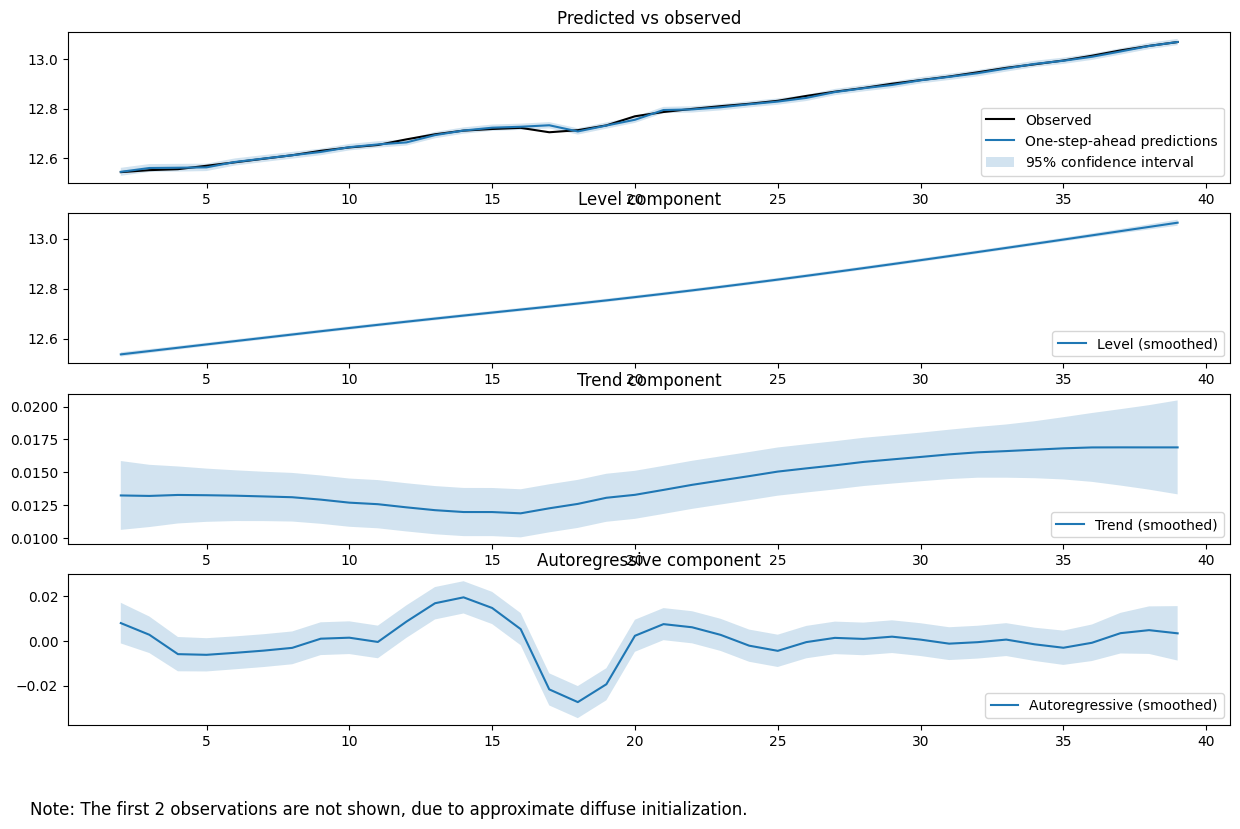

In [7]:
fig = output_res.plot_components(legend_loc='lower right', figsize=(15, 9));

In [17]:
potential_clark_uc          = np.exp(output_res.level['filtered'])
potential_growth_clark_uc   = output_res.trend['filtered']*100
output_gap_clark_uc         = output_res.autoregressive['filtered']*100

In [20]:
results_df = pd.DataFrame({
    'Сана': quarter_index,
    'Реал ЯИМ': data.rgdp,
    'Потенциал ЯИМ': potential_clark_uc,
    'Потенциал ЯИМ ўсиши': potential_growth_clark_uc,
    'ЯИМ тафовути': output_gap_clark_uc,
})


output_file = 'results\\clark_uc_results.xlsx'
results_df.to_excel(output_file, sheet_name='clark_uc', index=False)